<a href="https://colab.research.google.com/github/SubhadipJana1409/AI_and_Drug_Discovery_Course_2026/blob/main/Task1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Exploratory Data Analysis (EDA)**Course: Computational Drug Discovery**  **Dataset: ChEMBL Bioactivity Dataset**This notebook covers:- Basic statistics for pIC50- Histogram & density plot of pIC50- Bar plot of bioactivity class counts

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

## 1.1 Load Dataset

In [5]:
df = pd.read_csv('/content/data/bioactivity_preprocessed_data.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (6843, 4)
Columns: ['molecule_chembl_id', 'canonical_smiles', 'standard_value', 'bioactivity_class']


,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0,active


## 1.2 Basic Statistics for pIC50

In [9]:
# Convert 'standard_value' to numeric, coercing errors to NaN
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')

# Drop rows where 'standard_value' is NaN after conversion
df.dropna(subset=['standard_value'], inplace=True)

# Calculate pIC50 from 'standard_value' (assuming nM concentration, converting to M for -log10)
# Handle cases where standard_value might be zero or negative before log transformation
df['pIC50'] = df['standard_value'].apply(lambda x: -np.log10(x * 1e-9) if x > 0 else np.nan)

# Drop rows where pIC50 calculation resulted in NaN (e.g., from non-positive standard_value)
df.dropna(subset=['pIC50'], inplace=True)

stats = df['pIC50'].describe()
print("=" * 45)
print("     pIC50 Descriptive Statistics")
print("=" * 45)
print(f"  Count  : {stats['count']:.0f}")
print(f"  Mean   : {stats['mean']:.4f}")
print(f"  Std    : {stats['std']:.4f}")
print(f"  Min    : {stats['min']:.4f}")
print(f"  25%    : {stats['25%']:.4f}")
print(f"  Median : {stats['50%']:.4f}")
print(f"  75%    : {stats['75%']:.4f}")
print(f"  Max    : {stats['max']:.4f}")
print("=" * 45)

     pIC50 Descriptive Statistics
  Count  : 6842
  Mean   : 5.7961
  Std    : 1.5408
  Min    : 1.3045
  25%    : 4.7773
  Median : 5.6021
  75%    : 6.7696
  Max    : 14.3010


## 1.3 pIC50 Distribution – Histogram & Density Plot

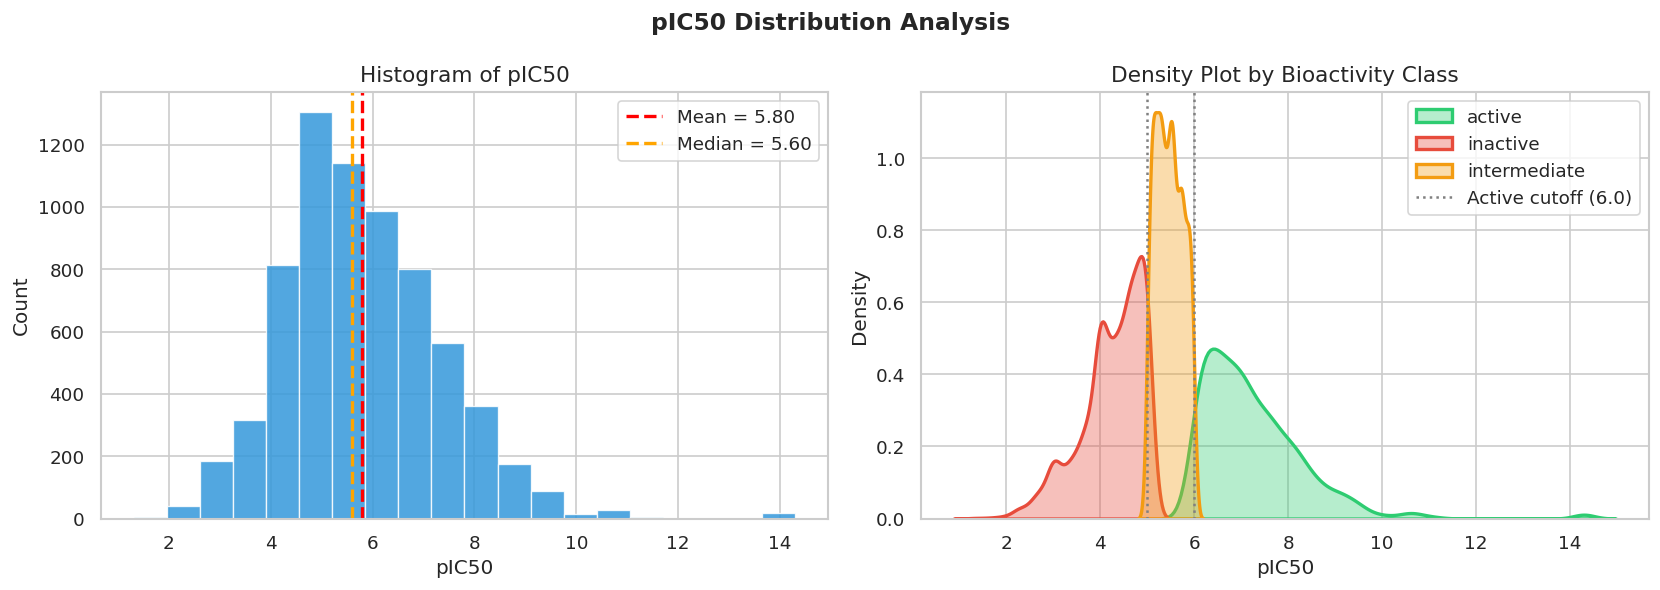

Figure saved.


In [14]:
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('pIC50 Distribution Analysis', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df['pIC50'], bins=20, color='#3498db', edgecolor='white', linewidth=0.8, alpha=0.85)
axes[0].axvline(df['pIC50'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean = {df['pIC50'].mean():.2f}")
axes[0].axvline(df['pIC50'].median(), color='orange', linestyle='--', linewidth=2,
                label=f"Median = {df['pIC50'].median():.2f}")
axes[0].set_xlabel('pIC50', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Histogram of pIC50', fontsize=13)
axes[0].legend()

# KDE Density by class
colors = {'active': '#2ecc71', 'inactive': '#e74c3c', 'intermediate': '#f39c12'}
for cls, grp in df.groupby('bioactivity_class'):
    sns.kdeplot(grp['pIC50'], ax=axes[1], label=cls, color=colors[cls],
                fill=True, alpha=0.35, linewidth=2)
axes[1].axvline(6.0, color='gray', linestyle=':', linewidth=1.5, label='Active cutoff (6.0)')
axes[1].axvline(5.0, color='gray', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('pIC50', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Density Plot by Bioactivity Class', fontsize=13)
axes[1].legend()

plt.tight_layout()

# Create the 'figures' directory if it doesn't exist
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/task1_pIC50_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## 1.4 Bioactivity Class Counts – Bar Plot

Bioactivity class distribution:
bioactivity_class
active          2815
inactive        2264
intermediate    1763
Name: count, dtype: int64


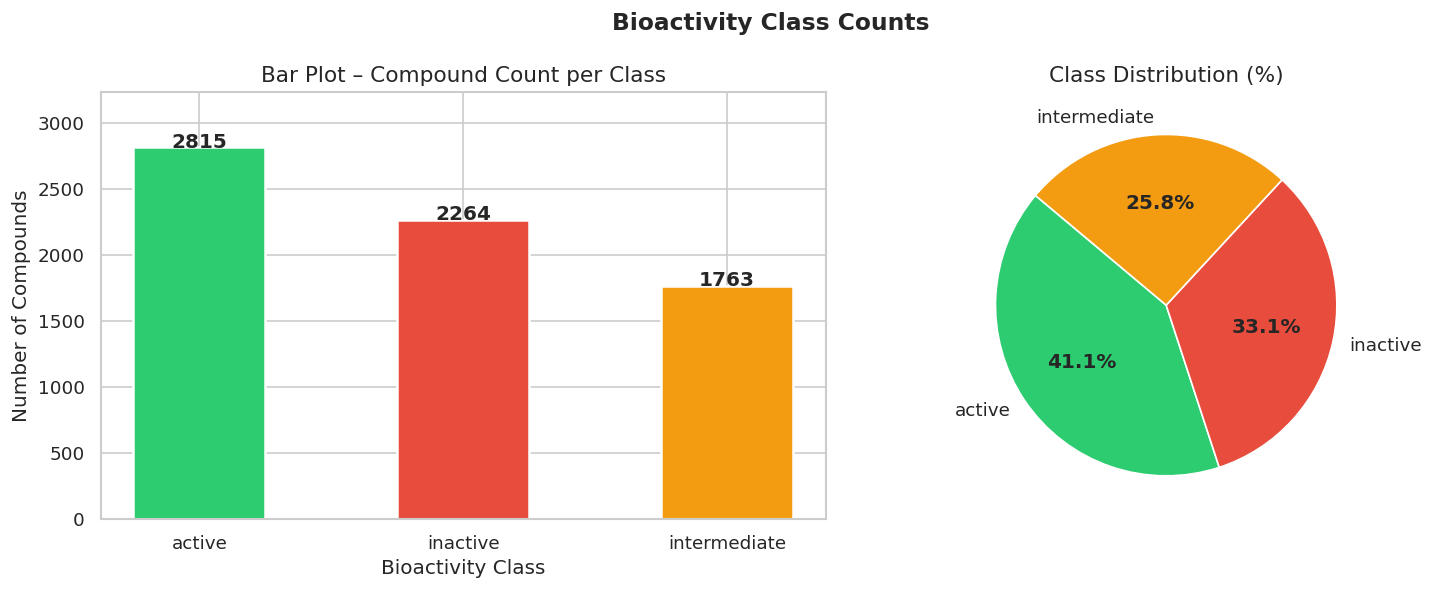

In [16]:
import os

counts = df['bioactivity_class'].value_counts()
print("Bioactivity class distribution:")
print(counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Bioactivity Class Counts', fontsize=14, fontweight='bold')

bars = axes[0].bar(counts.index, counts.values,
                   color=[colors[c] for c in counts.index],
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(v),
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Bioactivity Class', fontsize=12)
axes[0].set_ylabel('Number of Compounds', fontsize=12)
axes[0].set_title('Bar Plot – Compound Count per Class', fontsize=13)
axes[0].set_ylim(0, counts.max() * 1.15)

wedges, texts, autotexts = axes[1].pie(counts.values, labels=counts.index,
    autopct='%1.1f%%', colors=[colors[c] for c in counts.index], startangle=140)
for at in autotexts: at.set_fontweight('bold')
axes[1].set_title('Class Distribution (%)', fontsize=13)

plt.tight_layout()

# Create the 'figures' directory if it doesn't exist
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/task1_bioactivity_counts.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.5 pIC50 Box Plots by Class

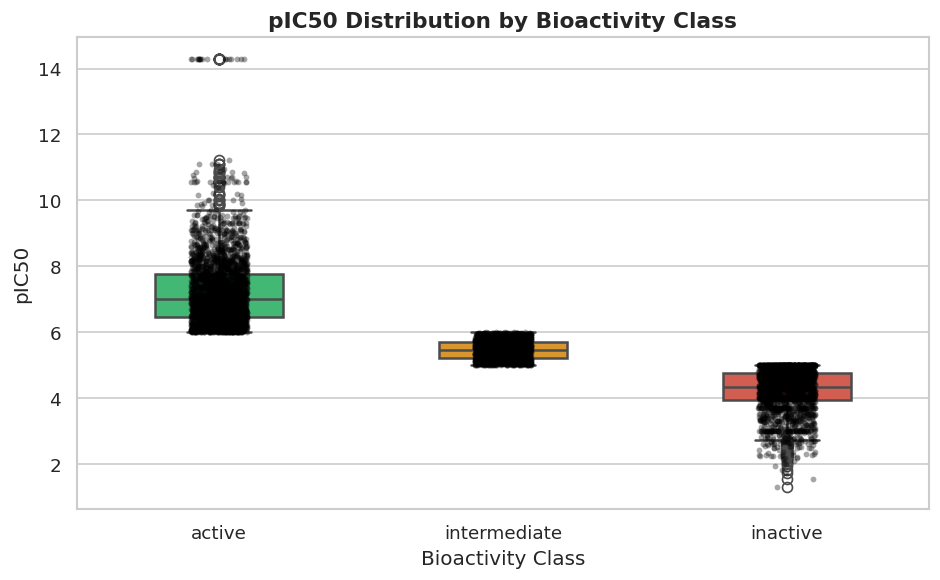

✅ Task 1 complete.


In [18]:
import os

fig, ax = plt.subplots(figsize=(8, 5))
order = ['active', 'intermediate', 'inactive']
palette = {c: colors[c] for c in colors}
sns.boxplot(data=df, x='bioactivity_class', y='pIC50', order=order,
            palette=palette, width=0.45, linewidth=1.5, ax=ax)
sns.stripplot(data=df, x='bioactivity_class', y='pIC50', order=order,
              color='black', alpha=0.35, size=3.5, ax=ax)
ax.set_title('pIC50 Distribution by Bioactivity Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Bioactivity Class', fontsize=12)
ax.set_ylabel('pIC50', fontsize=12)
plt.tight_layout()

# Create the 'figures' directory if it doesn't exist
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/task1_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Task 1 complete.")